In [10]:
import pandas as pd
import numpy as np

# 1. FRESH START: Load the raw data
df = pd.read_csv('../data/argan_cooperative_sales.csv')

# 2. Types Conversion & Currency Cleaning
currency_cols = ['unit_price_MAD', 'revenue_MAD', 'cost_MAD', 'profit_MAD']
for col in currency_cols:
    df[col] = df[col].astype(str).str.replace(r'[a-zA-Z$, ]', '', regex=True)
    df[col] = pd.to_numeric(df[col], errors='coerce')

# 3. Categorical Cleaning
categorical_cols = ['product', 'category', 'region', 'sales_channel', 'customer_type', 'branch']
for col in categorical_cols:
    df[col] = df[col].astype(str).str.title().str.strip()
    df[col] = df[col].astype('category')

# 4. Handling Mixed Booleans
boolean_map = {'Retailer': True, 'Local': False, 'Yes': True, 'No': False}
df['is_b2b_wholesale'] = df['customer_type'].map(boolean_map).fillna(False).astype(bool)

# 5. Date Parsing
df['date'] = pd.to_datetime(df['date'], errors='coerce')

# 6. Logical Integrity Checks
df = df.dropna(subset=['date'])
df['calculated_revenue'] = df['quantity'] * df['unit_price_MAD']
df = df[(df['quantity'] > 0) & (df['calculated_revenue'] == df['revenue_MAD'])]
df = df.drop(columns=['calculated_revenue'])

# 7. Handling Outliers (IQR Method)
Q1 = df['quantity'].quantile(0.25)
Q3 = df['quantity'].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df['quantity'] = np.where(df['quantity'] > upper_bound, upper_bound, df['quantity'])

# 8. String Parsing
df['volume_ml'] = df['product'].astype(str).str.extract(r'(\d+)ml')
df['volume_ml'] = df['volume_ml'].fillna(0).astype(int)

# 9. FINAL EXPORT
print("\n--- Pipeline Success! Cleaned Data Info ---")
print(df.info())
df.to_csv('Cleaned_Argan_Sales.csv', index=False)


--- Pipeline Success! Cleaned Data Info ---
<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    50000 non-null  int64         
 1   date              50000 non-null  datetime64[us]
 2   product           50000 non-null  category      
 3   category          50000 non-null  category      
 4   quantity          50000 non-null  float64       
 5   unit_price_MAD    50000 non-null  int64         
 6   revenue_MAD       50000 non-null  int64         
 7   cost_MAD          50000 non-null  float64       
 8   profit_MAD        50000 non-null  float64       
 9   region            50000 non-null  category      
 10  sales_channel     50000 non-null  category      
 11  customer_type     50000 non-null  category      
 12  branch            50000 non-null  category      
 13  is_b2b_wholesale  50000 non-null  bool    

C:\Users\Hp\AppData\Local\Temp\ipykernel_8348\2898937221.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(ax=axes[0], data=cat_profit, x='category', y='margin_pct', palette='Greens_r')


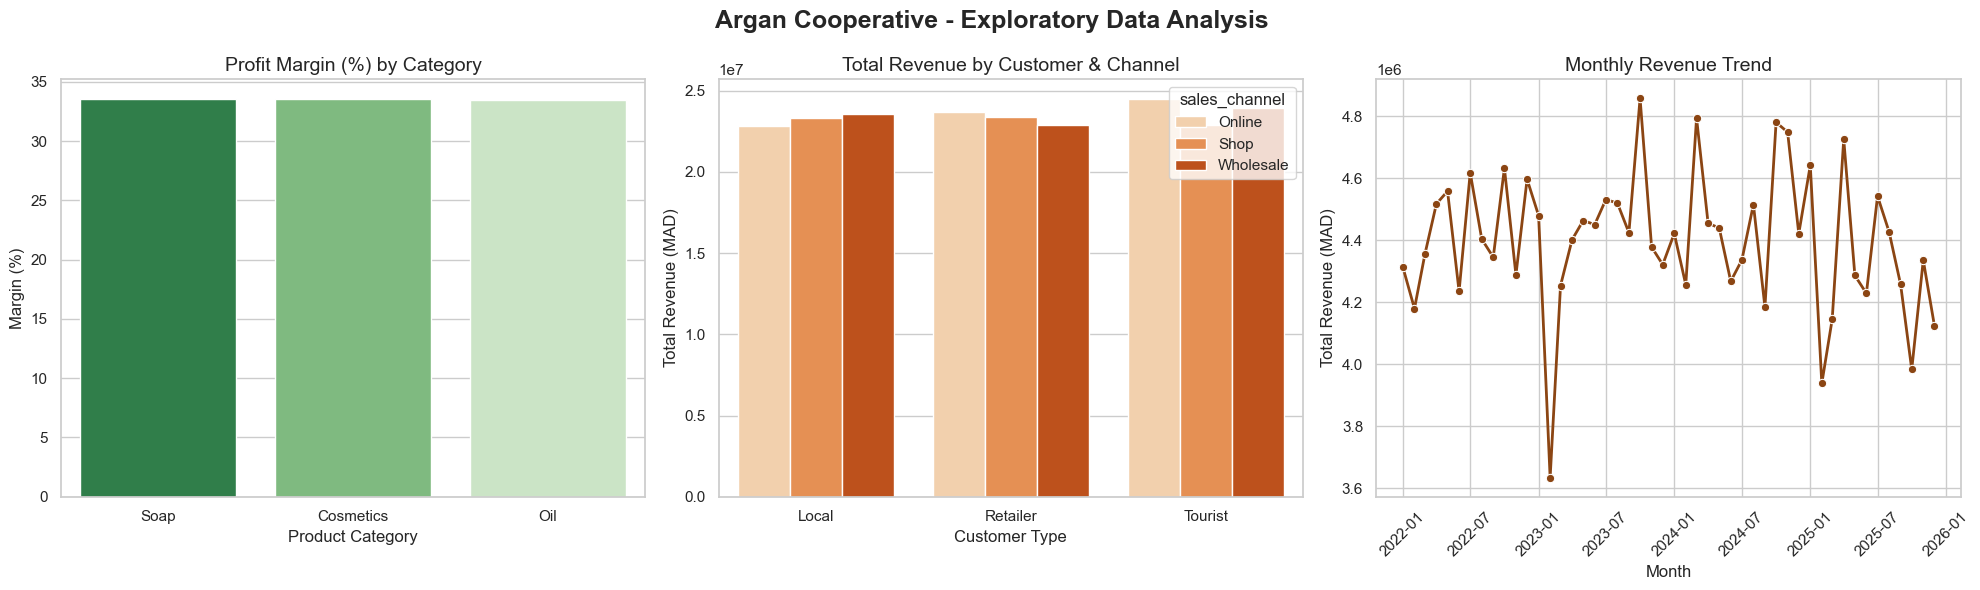

--- QUICK BUSINESS INSIGHTS ---
Total Cooperative Revenue: 211,018,076 MAD
Total Cooperative Profit: 70,653,325.99000001 MAD
Overall Profit Margin: 33.48%


In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Set visual style for the charts
sns.set_theme(style="whitegrid", palette="YlOrBr_r")

# Load the sparkling clean dataset
df = pd.read_csv('Cleaned_Argan_Sales.csv')
df['date'] = pd.to_datetime(df['date'])

# Create a figure with 3 subplots (1 row, 3 columns)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))
fig.suptitle('Argan Cooperative - Exploratory Data Analysis', fontsize=18, fontweight='bold')

# ==========================================
# CHART 1: Profit Margin by Product Category
# ==========================================
# FIXED: Using uppercase _MAD
cat_profit = df.groupby('category')[['revenue_MAD', 'profit_MAD']].sum().reset_index()
cat_profit['margin_pct'] = (cat_profit['profit_MAD'] / cat_profit['revenue_MAD']) * 100
cat_profit = cat_profit.sort_values('margin_pct', ascending=False)

sns.barplot(ax=axes[0], data=cat_profit, x='category', y='margin_pct', palette='Greens_r')
axes[0].set_title('Profit Margin (%) by Category', fontsize=14)
axes[0].set_ylabel('Margin (%)')
axes[0].set_xlabel('Product Category')

# ==========================================
# CHART 2: Revenue by Customer Type & Channel
# ==========================================
# FIXED: Using uppercase _MAD
cust_channel = df.groupby(['customer_type', 'sales_channel'])['revenue_MAD'].sum().reset_index()

sns.barplot(ax=axes[1], data=cust_channel, x='customer_type', y='revenue_MAD', hue='sales_channel', palette='Oranges')
axes[1].set_title('Total Revenue by Customer & Channel', fontsize=14)
axes[1].set_ylabel('Total Revenue (MAD)')
axes[1].set_xlabel('Customer Type')

# ==========================================
# CHART 3: Monthly Revenue Trend
# ==========================================
# Convert to the first day of each month
df['year_month'] = df['date'].dt.to_period('M').dt.to_timestamp()
# FIXED: Using uppercase _MAD
monthly_trend = df.groupby('year_month')['revenue_MAD'].sum().reset_index()
monthly_trend = monthly_trend.sort_values('year_month')

sns.lineplot(ax=axes[2], data=monthly_trend, x='year_month', y='revenue_MAD', marker='o', color='saddlebrown', linewidth=2)
axes[2].set_title('Monthly Revenue Trend', fontsize=14)
axes[2].set_ylabel('Total Revenue (MAD)')
axes[2].set_xlabel('Month')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

# FIXED: Using uppercase _MAD for the print statements
print("--- QUICK BUSINESS INSIGHTS ---")
print(f"Total Cooperative Revenue: {df['revenue_MAD'].sum():,} MAD")
print(f"Total Cooperative Profit: {df['profit_MAD'].sum():,} MAD")
print(f"Overall Profit Margin: {(df['profit_MAD'].sum() / df['revenue_MAD'].sum() * 100):.2f}%")